# AVAC analytical-verification figures

This notebook creates the Section 4 manuscript figures exclusively from the saved `publication_amr/results` products of the three AVAC case notebooks. It does not launch either solver, so later style and layout changes do not require new simulations.


## Reproducible environment

The first code cell installs the repository's validation package and Python dependencies into the active kernel. A clean checkout also needs GNU Make and gfortran to compile the selected solver on first use.


In [4]:
from pathlib import Path
SEARCH_ROOT = Path.cwd().resolve()
REPOSITORY = next(candidate for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents) if (candidate / 'validation' / 'pyproject.toml').is_file())
%pip install -q -e {REPOSITORY / 'validation'}


Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
from avac4qgis_validation import validation_case
case = validation_case('AVAC', 'Paper_figures')
CORES = max(1, os.cpu_count() or 1)
case.path


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/Paper_figures')

## Required numerical products

Run the WRR, Kerswell horizontal-Coulomb, and inclined-Coulomb notebooks first. Their summaries retain the solver hash, AMR controls, and achieved levels. The two Coulomb rows are postprocessed with one boundary definition: the wet support uses the solver dry tolerance and the undisturbed rear uses a 0.1% relative-depth tolerance so AMR interpolation noise is not mistaken for motion. Both the raw run summaries and the common manuscript diagnostics are archived with the figures.


In [6]:
case.run('make_avac_verification_figures.py', '--output-root', REPOSITORY / 'docs' / 'article' / 'figures')


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/Paper_figures/make_avac_verification_figures.py --output-root /Users/cmgotelli/Desktop/AVAC-QGIS/docs/article/figures
/Users/cmgotelli/Desktop/AVAC-QGIS/docs/article/figures


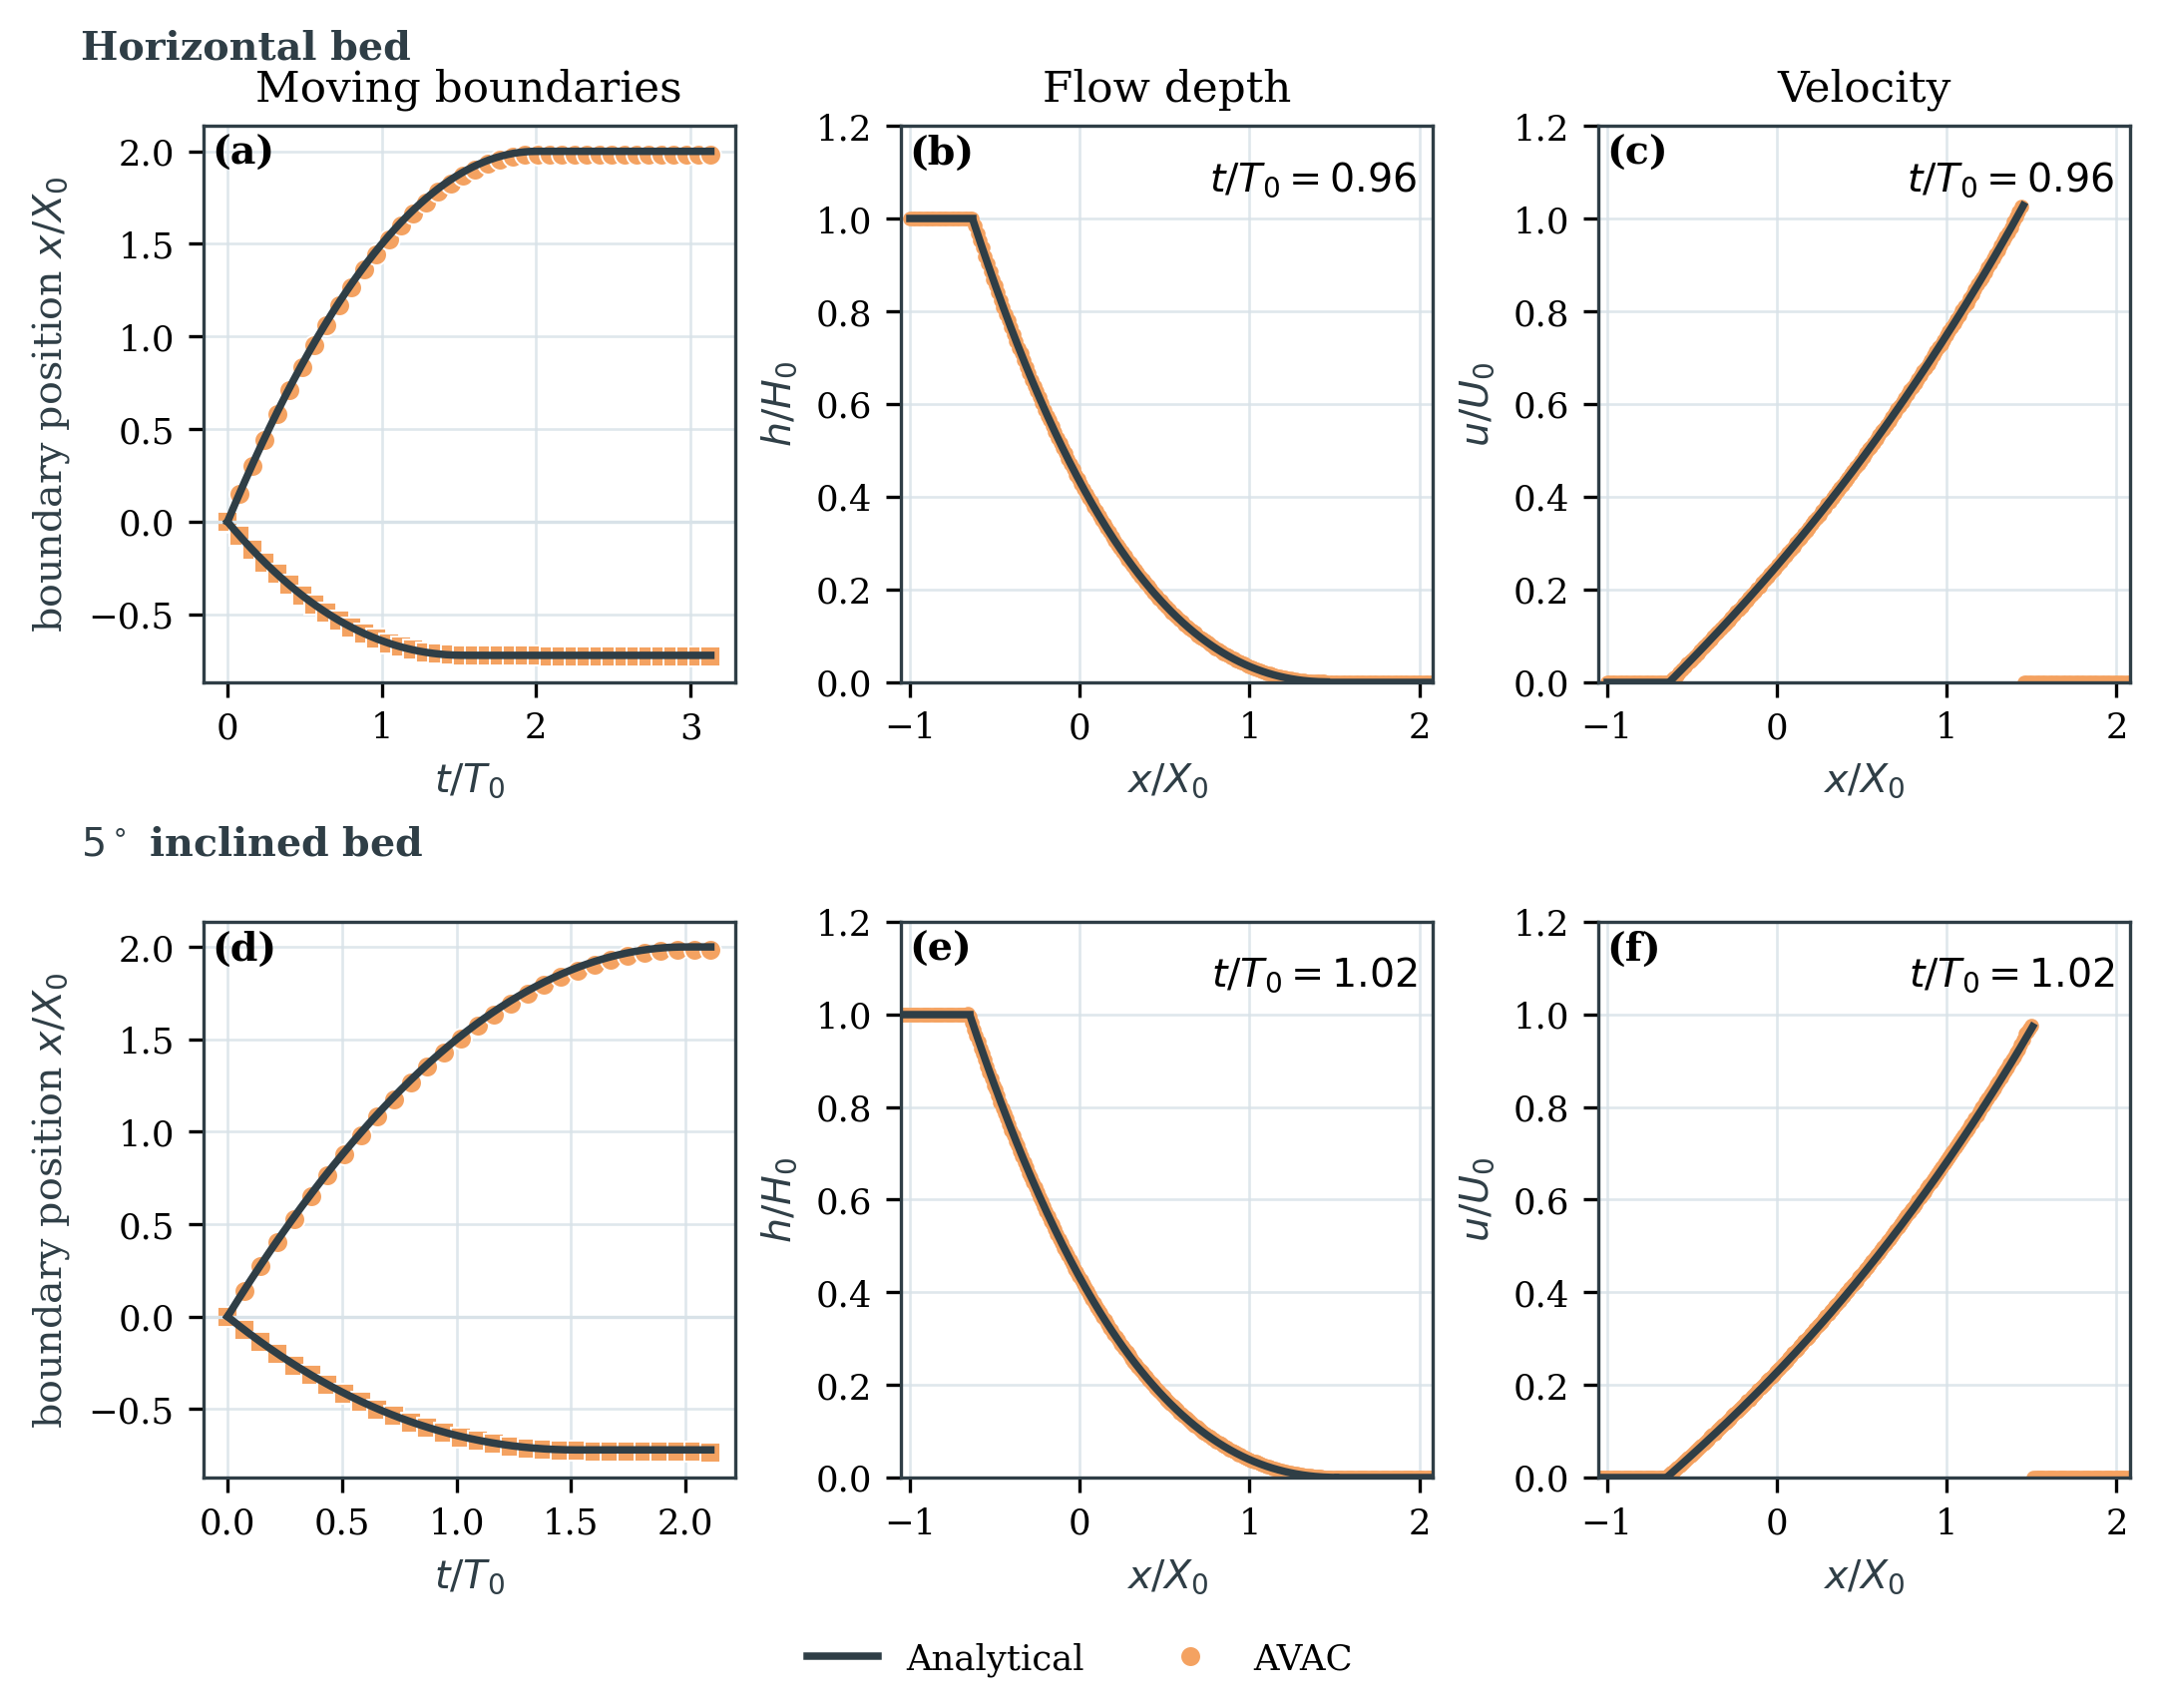

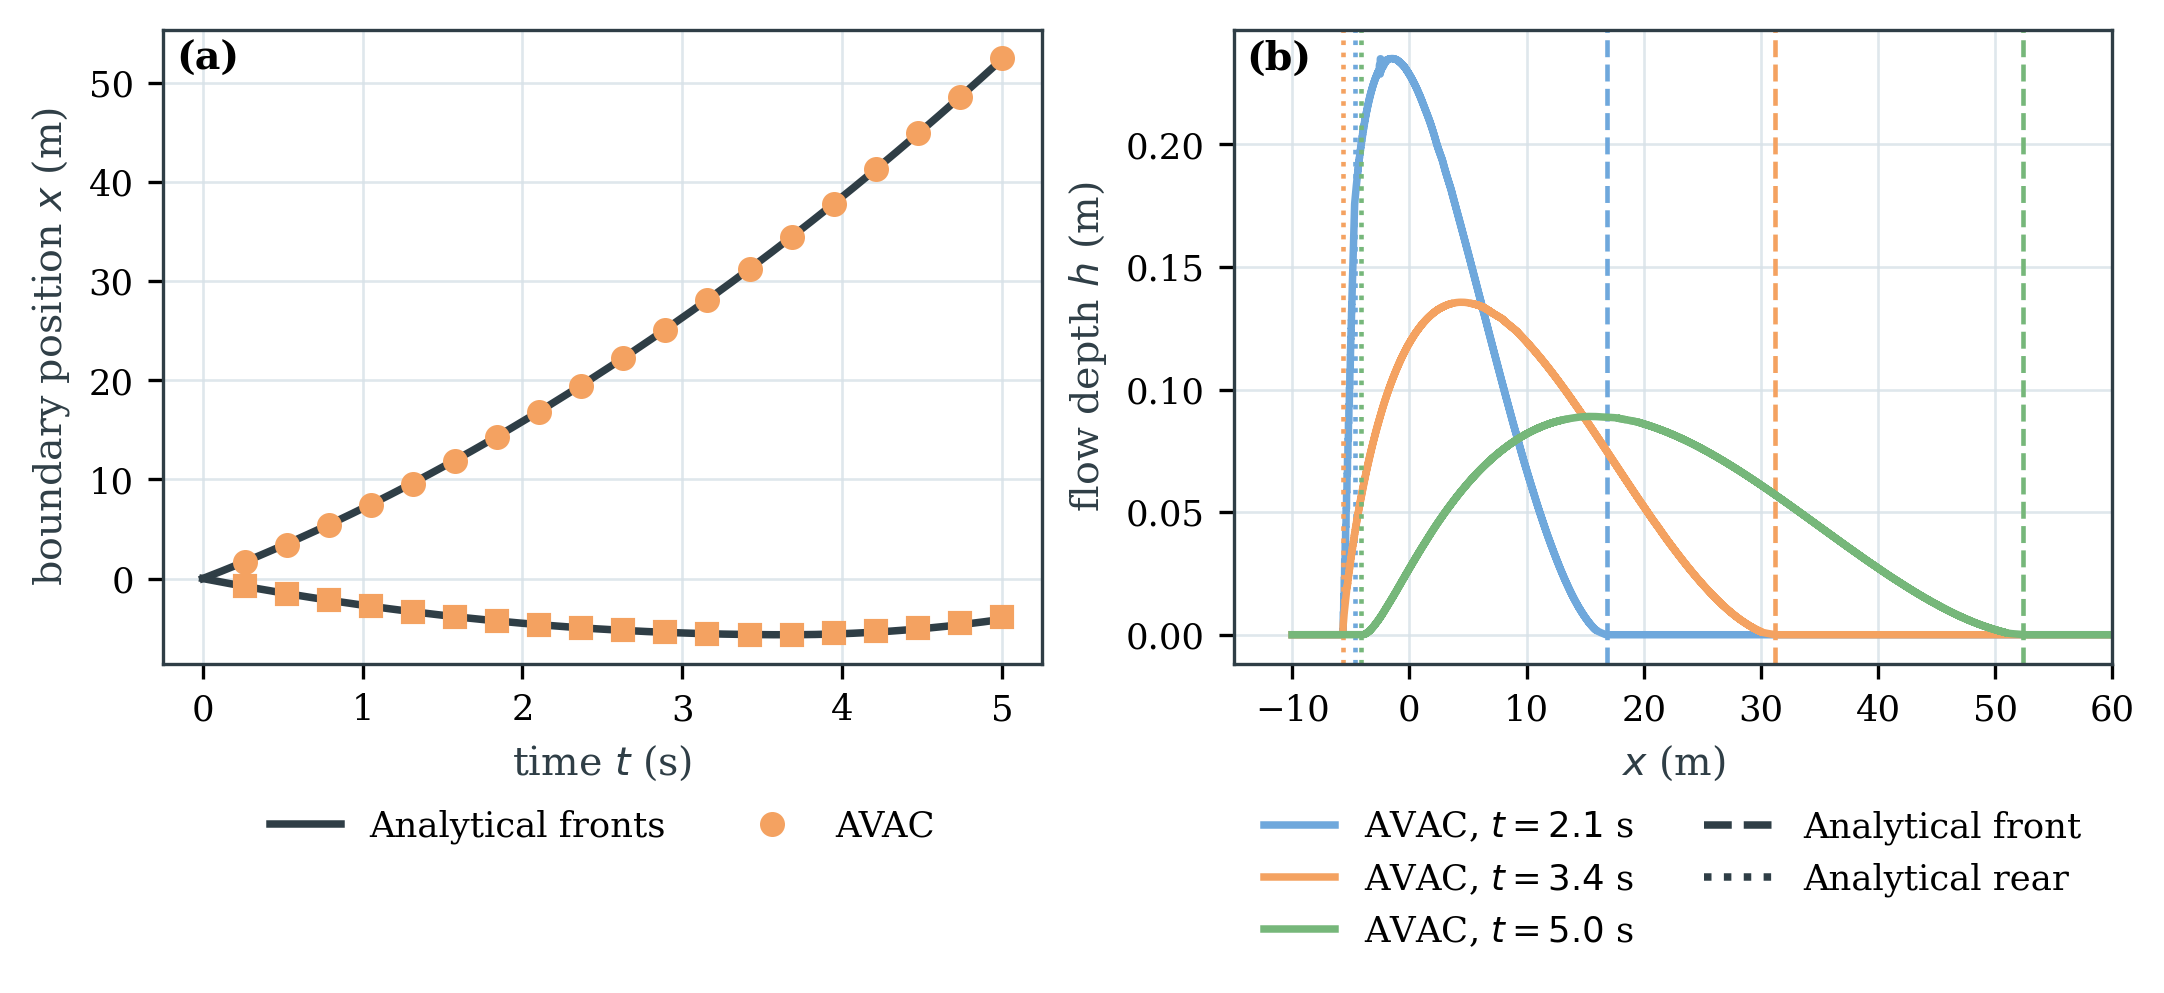

In [7]:
case.show('../../../docs/article/figures/avac_coulomb_verification.png', '../../../docs/article/figures/avac_wrr_water_limit.png')
